In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys
# append scripts
sys.path.append('../scripts')

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import scvi
import seaborn as sns
from tqdm import tqdm

import cellina
from cellina import CellinaModel
from cellina._spatial_utils import spatial_neighbors, compute_spatial_features

from perturb_utils import load_merfish_brain, split_indices

plt.rcParams['figure.dpi'] = 75
scvi.settings.seed = 0
print(cellina.__version__)

Global seed set to 0
Global seed set to 0


0.6.1


In [3]:
data_dir         = '/data2/a330d/datasets/MERFISH_mouse_brain'

In [250]:
adata_all = sc.read(f"{data_dir}/WB_MERFISH_animal2_coronal.h5ad")

In [331]:
adata_all.obs["brain_section_label"].value_counts()

brain_section_label
C57BL6J-2.039    51545
C57BL6J-2.034    49115
C57BL6J-2.036    48221
C57BL6J-2.041    46938
C57BL6J-2.033    46079
                 ...  
C57BL6J-2.015    15505
C57BL6J-2.013    13206
C57BL6J-2.003    12325
C57BL6J-2.002    10450
C57BL6J-2.001     7861
Name: count, Length: 66, dtype: int64

In [356]:
adata_all.obs["major_brain_region"].value_counts()

major_brain_region
Isocortex              422104
Olfactory              255805
Striatum               146523
Midbrain               140234
Hippocampus            136995
Fiber_tracts           136567
Cerebellum              65386
Thalamus                61891
Hypothalamus            60499
Pons                    58471
Medulla                 35967
Pallidum                29614
Ventricular_systems     27039
Cortical_subplate       25579
Name: count, dtype: int64

In [45]:
# ── Brain LOO Config ─────────────────────────────────────────────────────────
labels_key       = 'cell_type'
domains_key      = 'major_brain_region'
holdout_celltype = 'glutamatergic neuron'
donor_region     = 'Thalamus'
target_regions   = ['Isocortex', 'Fiber_tracts']
top_n_perturb    = 100   # genes used to perturb spatial context
top_n            = 100   # genes used to evaluate metrics
min_cells        = 50    # minimum cells per domain per cell type to evaluate
batch_size       = 2048
library_size     = 1e4
base_path        = '/data2/a330d/data/perturb_loo_brain'
exp_name         = f"{donor_region}_to_{'_'.join(target_regions)}"
save_path        = f"{base_path}/trained/{exp_name}_{holdout_celltype.replace(' ', '_')}"
data_dir         = '/data2/a330d/datasets/MERFISH_mouse_brain'
brain_section    = 'C57BL6J-2.039'

In [46]:
adata = load_merfish_brain(data_dir=data_dir,
                           brain_section_label=brain_section,
                           labels_key=labels_key, 
                           domains_key=domains_key)

/tmp/ipykernel_481414/4283215232.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_ct_counts = adata_all.obs.groupby([domains_key, labels_key]).size().unstack(fill_value=0)


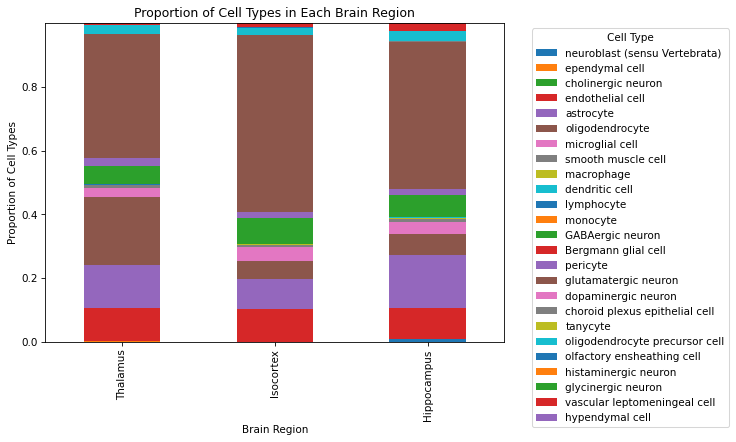

In [354]:
# Plot proportion of celltypes in each of the regions in donor_region + target_regions
region_ct_counts = adata_all.obs.groupby([domains_key, labels_key]).size().unstack(fill_value=0)
region_counts = adata_all.obs[domains_key].value_counts()
region_ct_proportions = region_ct_counts.div(region_counts, axis=0)
region_ct_proportions = region_ct_proportions.loc[[donor_region] + target_regions]
region_ct_proportions.plot(kind='bar', stacked=True, figsize=(10, 6 ))
plt.title('Proportion of Cell Types in Each Brain Region')
plt.xlabel('Brain Region')
plt.ylabel('Proportion of Cell Types')
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_481414/2919107247.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_ct_counts = adata.obs.groupby([domains_key, labels_key]).size().unstack(fill_value=0)


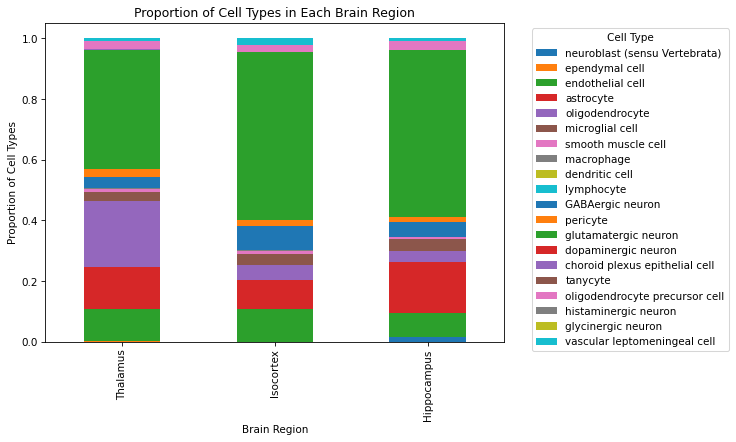

In [353]:
# Plot proportion of celltypes in each of the regions in donor_region + target_regions
region_ct_counts = adata.obs.groupby([domains_key, labels_key]).size().unstack(fill_value=0)
region_counts = adata.obs[domains_key].value_counts()
region_ct_proportions = region_ct_counts.div(region_counts, axis=0)
region_ct_proportions = region_ct_proportions.loc[[donor_region] + target_regions]
region_ct_proportions.plot(kind='bar', stacked=True, figsize=(10, 6 ))
plt.title('Proportion of Cell Types in Each Brain Region')
plt.xlabel('Brain Region')
plt.ylabel('Proportion of Cell Types')
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [47]:
adata.obs[domains_key].value_counts()

major_brain_region
Isocortex              13314
Thalamus                8963
Hippocampus             7097
Fiber_tracts            6052
Hypothalamus            4871
Cortical_subplate       2935
Striatum                2538
Olfactory               1921
Ventricular_systems     1688
Name: count, dtype: int64

In [48]:
adata.obs[labels_key].value_counts()

cell_type
glutamatergic neuron              19633
oligodendrocyte                    6465
astrocyte                          6350
GABAergic neuron                   5278
endothelial cell                   4114
microglial cell                    1640
oligodendrocyte precursor cell     1443
vascular leptomeningeal cell        989
pericyte                            906
choroid plexus epithelial cell      744
ependymal cell                      696
neuroblast (sensu Vertebrata)       355
smooth muscle cell                  343
tanycyte                            182
macrophage                          146
lymphocyte                           45
dopaminergic neuron                  15
histaminergic neuron                 14
dendritic cell                       13
glycinergic neuron                    5
monocyte                              2
cholinergic neuron                    1
Name: count, dtype: int64

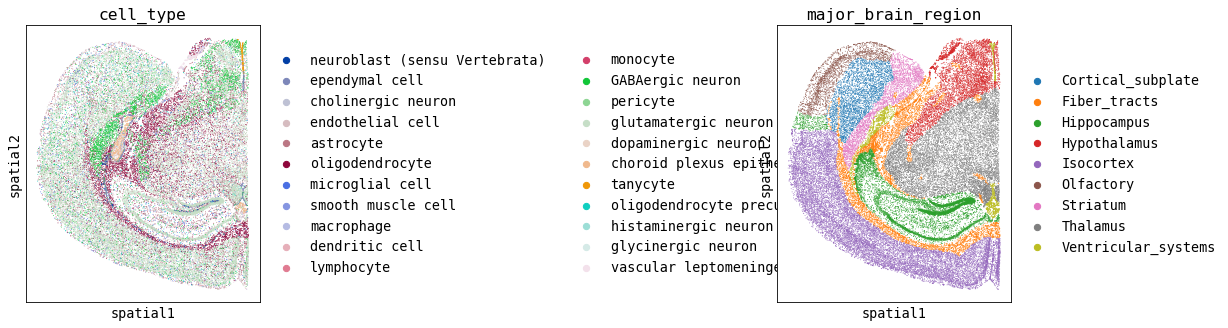

In [49]:
sc.pl.spatial(adata, color=[labels_key, domains_key], spot_size=20, wspace=0.6)

In [50]:
adata.obs[[labels_key, domains_key]].groupby([labels_key, domains_key]).size().sort_values(ascending=False).head(20)

cell_type             major_brain_region
glutamatergic neuron  Isocortex             7730
                      Thalamus              3521
                      Hippocampus           3203
oligodendrocyte       Fiber_tracts          2455
                      Thalamus              1769
glutamatergic neuron  Cortical_subplate     1506
                      Hypothalamus          1349
astrocyte             Isocortex             1295
endothelial cell      Isocortex             1256
astrocyte             Thalamus              1230
GABAergic neuron      Striatum              1142
                      Hypothalamus          1123
astrocyte             Hippocampus           1081
GABAergic neuron      Isocortex             1041
endothelial cell      Thalamus               996
astrocyte             Fiber_tracts           933
glutamatergic neuron  Olfactory              878
oligodendrocyte       Hippocampus            695
glutamatergic neuron  Striatum               688
oligodendrocyte       Hypoth

In [423]:
# Normalize adata.X for compute_spatial_features
sc.pp.normalize_total(adata, target_sum=1e4)

In [51]:
all_regions = [donor_region] + target_regions
adata_3r = adata.copy() #adata[adata.obs[domains_key].isin(all_regions)].copy()
print(f"Subset: {adata_3r.shape}")
print(adata_3r.obs.groupby([domains_key, labels_key]).size().unstack(fill_value=0))

Subset: (49379, 1120)
cell_type            neuroblast (sensu Vertebrata)  ependymal cell  \
major_brain_region                                                   
Cortical_subplate                                3               0   
Fiber_tracts                                   114             135   
Hippocampus                                    186             194   
Hypothalamus                                     0              36   
Isocortex                                        0               0   
Olfactory                                       27               0   
Striatum                                         4               3   
Thalamus                                         0              39   
Ventricular_systems                             21             289   

cell_type            cholinergic neuron  endothelial cell  astrocyte  \
major_brain_region                                                     
Cortical_subplate                     0               215      

/tmp/ipykernel_481414/1340041383.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_3r, color=[labels_key, domains_key], spot_size=20, wspace=0.6)


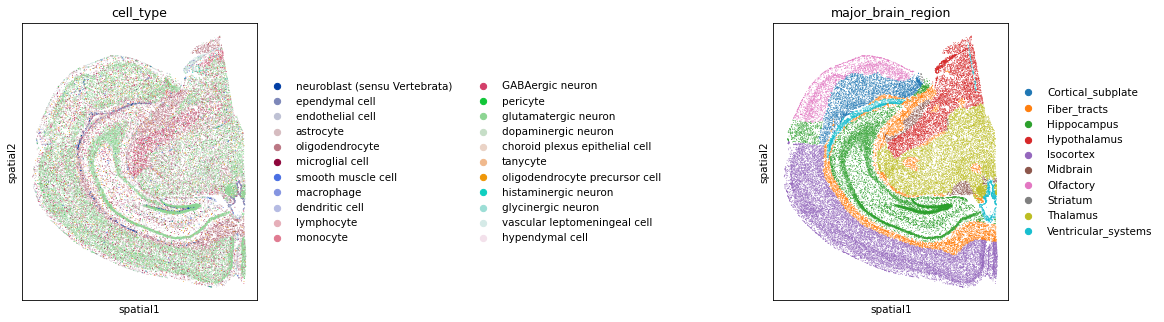

In [425]:
sc.pl.spatial(adata_3r, color=[labels_key, domains_key], spot_size=20, wspace=0.6)

In [426]:
# Spatial graph on the 3-region subset (CCF coords in microns — no pixel conversion)
spatial_neighbors(adata_3r, bandwidth=100, max_neighbours=200, standardize=False)
compute_spatial_features(adata_3r)

In [14]:
# Hold out glutamatergic neurons from BOTH Thalamus AND Hippocampus simultaneously
train_idx, val_idx, test_idx = split_indices(
    adata_3r,
    holdout_celltype=holdout_celltype,
    labels_key=labels_key,
    domains_key=domains_key,
    holdout_domains=tuple(target_regions),  # ('Thalamus', 'Hippocampus')
)
print(f"train={len(train_idx):,}  val={len(val_idx):,}  test (holdout)={len(test_idx):,}")
print(f"Holdout = {holdout_celltype} in {target_regions}: {adata_3r.obs['is_holdout'].sum()} cells")

train=38,390  val=4,265  test (holdout)=6,724
Holdout = glutamatergic neuron in ['Thalamus', 'Hippocampus']: 6724 cells


## Cellina

In [16]:
CellinaModel.setup_anndata(
    adata_3r,
    batch_key=None,
    labels_key=labels_key,
    domains_key=domains_key,
    layer='counts',
    spatial_obsm_key='spatial_x',
)

model = CellinaModel(
    adata_3r,
    n_latent=64,
    classifier_lambda=1,
    discriminator_lambda=1,
    n_layers=2,
    condition_on_intrinsic=False,
)

INFO     Generating sequential column names                                                                        
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 2 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(


In [17]:
model.train(
    max_epochs=100,
    check_val_every_n_epoch=1,
    early_stopping=True,
    early_stopping_patience=5,
    early_stopping_monitor='vae_loss_validation',
    plan_kwargs={'lr': 1e-3, 'weight_decay': 0.0001, 'normalize_losses': True},
    datasplitter_kwargs={"external_indexing": [train_idx, val_idx, test_idx]},
    enable_checkpointing=True,
    batch_size=batch_size,
    devices=[0],
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers 

Epoch 40/100:  40%|████      | 40/100 [00:22<00:33,  1.82it/s, v_num=1, train_loss=-228]
Monitored metric vae_loss_validation did not improve in the last 5 records. Best score: 419.358. Signaling Trainer to stop.


In [20]:
model.save(save_path, overwrite=True)

In [ ]:
model = CellinaModel.load(save_path, adata=adata_3r)

## Inference

In [15]:
from scipy.stats import pearsonr, spearmanr
from counterfactual_analysis import safe_log2_fold_change, precision_at_k, _normalize_counts

def compute_correlations(control, target, counterfactual, normalize_counts=True, deg=200):
    if normalize_counts:
        control = _normalize_counts(control)
        target = _normalize_counts(target)
        counterfactual = _normalize_counts(counterfactual)

    mean_control = np.nanmean(control, axis=0)
    mean_target = np.nanmean(target, axis=0)
    mean_cf = np.nanmean(counterfactual, axis=0)

    # compute log2 fold changes
    gt_vec = safe_log2_fold_change(mean_target, mean_control)
    cf_vec = safe_log2_fold_change(mean_cf, mean_control)

    deg_scores = np.abs(gt_vec)
    top_features = np.argsort(-deg_scores)[:deg]
    pear, _ = pearsonr(gt_vec[top_features], cf_vec[top_features])
    spear, _ = spearmanr(gt_vec[top_features], cf_vec[top_features])
    prec = precision_at_k(gt_vec, cf_vec, k=deg, use_abs=True)
    """
    # Plot scatterplot of gt vs cf log fold changes - highlight top features in a different color
    import matplotlib.pyplot as plt
    plt.scatter(gt_vec, cf_vec)
    plt.xlabel('Ground Truth Log2 Fold Change')
    plt.ylabel('Counterfactual Log2 Fold Change')
    plt.title('GT vs CF Log2 Fold Change')
    
    # highlight top features in a different color
    plt.scatter(gt_vec[top_features], cf_vec[top_features], color='red')
    plt.show()
    """
    return float(pear), float(spear), float(prec), top_features

In [16]:
def compute_rmse(observed_target, pred_target, normalize_counts=True, log1p=True, deg=None, library_size=1e4):
    """
    Compute RMSE between psuedobulked observed and counterfactual counts for holdout cells.
    """
    # Subset to DE genes if deg provided; otherwise use all genes
    top_features = deg if deg is not None else np.arange(observed_target.shape[1])
    observed_target = observed_target[:, top_features]
    pred_target = pred_target[:, top_features]

    if normalize_counts:
        observed_target = _normalize_counts(observed_target, scale=library_size)
        pred_target = _normalize_counts(pred_target, scale=library_size)
    if log1p:
        observed_target = np.log1p(observed_target)
        pred_target = np.log1p(pred_target)

    observed_pseudobulk = observed_target.sum(axis=0)
    pred_pseudobulk = pred_target.sum(axis=0)

    return np.sqrt(np.mean((observed_pseudobulk - pred_pseudobulk) ** 2))

In [21]:
adata_3r.obsm['recon_x'] = model.get_normalized_expression(batch_size=batch_size, library_size=library_size)

In [23]:
adata_ct = adata_3r[adata_3r.obs[labels_key] == holdout_celltype].copy()

In [53]:
celltypes = ['glutamatergic neuron', 'oligodendrocyte', 'astrocyte', 'GABAergic neuron', 'endothelial cell']
results = {k: adata_3r[adata_3r.obs[labels_key] == k].copy() for k in celltypes}

In [54]:
for ct in tqdm(celltypes, desc=f"Cell types"):
    # Control set is same - only target changes (either crc_all or microenv labels)
    is_celltype = adata_3r.obs[labels_key].astype(str) == ct

    is_donor_region = adata_3r.obs[domains_key]==donor_region
    mask_control = is_donor_region & is_celltype
    idx_control = np.where(mask_control.values)[0]

    for target_domain in target_regions:
        is_target_region = adata_3r.obs[domains_key]==target_domain
        mask_target = is_target_region & is_celltype
        idx_target = np.where(mask_target.values)[0]

        args = {
                    "adata": adata_3r,
                    "indices": idx_control,
                    "neighbour_indices": idx_target,
                    "batch_size": 4096,
                    "seed": 0,
                }
        results[ct].uns[f'counterfactual_x_{target_domain}'] = model.get_counterfactual_expression(**args, library_size=1e4)
        results[ct].uns[f'counterfactual_latents_{target_domain}'] = model.get_counterfactual_latents(**args, latent_key='shifted')

Cell types:   0%|          | 0/5 [00:00<?, ?it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


Cell types:  20%|██        | 1/5 [00:00<00:02,  1.92it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


Cell types:  40%|████      | 2/5 [00:00<00:00,  3.66it/s]

...

Cell types:  60%|██████    | 3/5 [00:00<00:00,  4.74it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


Cell types:  80%|████████  | 4/5 [00:00<00:00,  5.62it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


Cell types: 100%|██████████| 5/5 [00:01<00:00,  4.89it/s]


In [55]:
summary = []
deg = 200

for ct, dataset in tqdm(results.items(), desc="Computing correlations"):
    is_donor_region = dataset.obs[domains_key]==donor_region
    mask_control = is_donor_region

    control = dataset.layers['counts'].todense()[mask_control]
    control = np.asarray(control)
    
    for target_domain in target_regions:
        is_target_region = dataset.obs[domains_key]==target_domain
        mask_target = is_target_region
        target = dataset.layers['counts'].todense()[mask_target]
        target = np.asarray(target)

        counterfactual = dataset.uns[f'counterfactual_x_{target_domain}']
        pear, spear, prec = compute_correlations(control, target, counterfactual, deg=deg)

        summary.append({
            "cell_type": ct,
            "source_domain": donor_region,
            "target_domain": target_domain,
            "pearson": np.round(pear, 4),
            "spearman": np.round(spear, 4),
            "precision": np.round(prec, 4),
            "method": "cellina",
        })

Computing correlations: 100%|██████████| 5/5 [00:00<00:00, 15.98it/s]


In [ ]:
summary_df = pd.DataFrame(summary)

In [ ]:
summary_df

,cell_type,source_domain,target_domain,pearson,spearman,precision,method
0,glutamatergic neuron,Isocortex,Thalamus,0.9135,0.8759,0.425,cellina
1,glutamatergic neuron,Isocortex,Hippocampus,0.7997,0.7788,0.275,cellina
2,oligodendrocyte,Isocortex,Thalamus,0.9543,0.9015,0.580,cellina
3,oligodendrocyte,Isocortex,Hippocampus,0.6456,0.4084,0.385,cellina
4,astrocyte,Isocortex,Thalamus,0.7859,0.8392,0.470,cellina
5,astrocyte,Isocortex,Hippocampus,0.6394,0.7083,0.425,cellina
6,GABAergic neuron,Isocortex,Thalamus,0.7858,0.8644,0.470,cellina
7,GABAergic neuron,Isocortex,Hippocampus,0.3263,0.3921,0.295,cellina
8,endothelial cell,Isocortex,Thalamus,0.6829,0.8108,0.465,cellina
9,endothelial cell,Isocortex,Hippocampus,0.3595,0.3813,0.430,cellina


In [ ]:
# Save df
summary_df.to_csv(f"../results/merfish_loo.csv", index=False)

## LOO -  Cellina

In [427]:
from configs.cellina_config import MODEL_ARGS, TRAIN_ARGS, PLAN_KWARGS

In [428]:
holdout_celltypes = ['glutamatergic neuron', 'oligodendrocyte', 'astrocyte', 'GABAergic neuron', 'endothelial cell']

CellinaModel.setup_anndata(
        adata_3r,
        batch_key=None,
        labels_key=labels_key,
        domains_key=domains_key,
        layer='counts',
        spatial_obsm_key='spatial_x',
    )

INFO     Generating sequential column names                                                                        


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 16 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(


In [429]:
for ct in tqdm(holdout_celltypes):
    print(f"{'=' * 50} Holdout cell type: {ct} {'=' * 50}")
    train_idx, val_idx, test_idx = split_indices(
        adata_3r,
        holdout_celltype=ct,
        labels_key=labels_key,
        domains_key=domains_key,
        holdout_domains=tuple(target_regions),
    )
    print(f"train={len(train_idx):,}  val={len(val_idx):,}  test (holdout)={len(test_idx):,}")
    print(f"Holdout = {ct} in {target_regions}: {adata_3r.obs['is_holdout'].sum()} cells")

    model = CellinaModel(
        adata_3r,
        **MODEL_ARGS,
    )
    TRAIN_ARGS['datasplitter_kwargs'] = {
                  "external_indexing": [train_idx, val_idx, test_idx],
                  }
    model.train(**TRAIN_ARGS, plan_kwargs=PLAN_KWARGS)

    save_path = f"{base_path}/trained/merfish_loo/{brain_section}/{ct}"
    model.save(save_path, overwrite=True)

  0%|          | 0/5 [00:00<?, ?it/s]

================================================== Holdout cell type: glutamatergic neuron ==================================================
train=34,014  val=3,779  test (holdout)=7,777
Holdout = glutamatergic neuron in ['Isocortex', 'Fiber_tracts']: 7777 cells
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 55/100:  55%|█████▌    | 55/100 [00:23<00:19,  2.29it/s, v_num=1, train_loss=-218]

 20%|██        | 1/5 [00:24<01:36, 24.22s/it]

...


Monitored metric vae_loss_validation did not improve in the last 5 records. Best score: 353.382. Signaling Trainer to stop.
================================================== Holdout cell type: endothelial cell ==================================================
train=39,701  val=4,411  test (holdout)=1,458
Holdout = endothelial cell in ['Isocortex', 'Fiber_tracts']: 1458 cells
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 63/100:  63%|██████▎   | 63/100 [00:32<00:18,  1.96it/s, v_num=1, train_loss=-230]

100%|██████████| 5/5 [02:16<00:00, 27.21s/it]


Monitored metric vae_loss_validation did not improve in the last 5 records. Best score: 352.273. Signaling Trainer to stop.


In [430]:
results = {k: adata_3r[adata_3r.obs[labels_key] == k].copy() for k in holdout_celltypes}
summary = []

In [431]:
for ct in tqdm(holdout_celltypes, desc=f"Cell types"):
    # load model
    save_path = f"{base_path}/trained/merfish_loo/{brain_section}/{ct}" 
    model = CellinaModel.load(save_path, adata=adata_3r)

    adata_3r.obsm['recon_x'] = model.get_normalized_expression(batch_size=batch_size, library_size=library_size)
    
    # Generate counterfactuals for each target domain
    is_donor_region = results[ct].obs[domains_key]==donor_region
    mask_control = is_donor_region
    idx_control = np.where(mask_control.values)[0]

    for target_domain in target_regions:
        is_target_region = results[ct].obs[domains_key]==target_domain
        mask_target = is_target_region
        idx_target = np.where(mask_target.values)[0]

        args = {
                    "adata": results[ct],
                    "indices": idx_control,
                    "neighbour_indices": idx_target,
                    "batch_size": 4096,
                    "seed": 0,
                }
        results[ct].uns[f'counterfactual_x_{target_domain}'] = model.get_counterfactual_expression(**args, library_size=library_size)
        results[ct].uns[f'counterfactual_latents_{target_domain}'] = model.get_counterfactual_latents(**args, latent_key='shifted')

    # Compute stats
    control = results[ct].layers['counts'].todense()[mask_control]
    control = np.asarray(control)
    
    for target_domain in target_regions:
        target = results[ct].layers['counts'].todense()[mask_target]
        target = np.asarray(target)

        counterfactual = results[ct].uns[f'counterfactual_x_{target_domain}']
        pear, spear, prec, deg = compute_correlations(control, target, counterfactual, deg=top_n)
        rmse = compute_rmse(observed_target=target, pred_target=counterfactual, deg=deg)

        summary.append({
            "cell_type": ct,
            "source_domain": donor_region,
            "target_domain": target_domain,
            "pearson": np.round(pear, 4),
            "spearman": np.round(spear, 4),
            "precision": np.round(prec, 4),
            "rmse": np.round(rmse, 4),
            "method": "cellina",
        })

Cell types:   0%|          | 0/5 [00:00<?, ?it/s]Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/perturb_loo_brain/trained/merfish_loo/C57BL6J-2.041/glutamatergic neuron/model.pt  
         already downloaded                                                                                        
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 16 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


Cell types:  20%|██        | 1/5 [00:00<00:01,  2.01it/s]Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


...

Cell types:  80%|████████  | 4/5 [00:01<00:00,  2.55it/s]Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/perturb_loo_brain/trained/merfish_loo/C57BL6J-2.041/endothelial cell/model.pt      
         already downloaded                                                                                        
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 16 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


Cell types: 100%|██████████| 5/5 [00:02<00:00,  2.49it/s]


In [432]:
summary_df = pd.DataFrame(summary)

In [433]:
summary_df

,cell_type,source_domain,target_domain,pearson,spearman,precision,rmse,method
0,glutamatergic neuron,Thalamus,Isocortex,0.8693,0.8129,0.50,10093.941406,cellina
1,glutamatergic neuron,Thalamus,Fiber_tracts,0.9139,0.8493,0.58,9844.564453,cellina
2,oligodendrocyte,Thalamus,Isocortex,0.6954,0.2092,0.31,4558.509766,cellina
3,oligodendrocyte,Thalamus,Fiber_tracts,0.7437,0.2689,0.49,4862.654785,cellina
4,astrocyte,Thalamus,Isocortex,0.5741,0.6890,0.43,2576.526855,cellina
5,astrocyte,Thalamus,Fiber_tracts,0.6087,0.7123,0.53,2281.037598,cellina
6,GABAergic neuron,Thalamus,Isocortex,0.6009,0.6948,0.51,1183.894775,cellina
7,GABAergic neuron,Thalamus,Fiber_tracts,0.6079,0.7127,0.52,1186.634644,cellina
8,endothelial cell,Thalamus,Isocortex,0.9928,0.8004,0.24,2915.564453,cellina
9,endothelial cell,Thalamus,Fiber_tracts,0.9945,0.8173,0.25,2944.926025,cellina


## LOO - Baseline

In [434]:
from counterfactual_analysis import _normalize_counts, _to_dense

def get_baseline_delta(
    adata_control,
    adata_target,
    normalize_counts=False,
    eps=1e-8,
):
    # Take log fold change delta of in-sample control and CRC populations    
    x = adata_control.layers["counts"].toarray()
    y = adata_target.layers["counts"].toarray()
    if normalize_counts:
        # normalize to proportions
        x = _normalize_counts(x, eps=eps)
        y = _normalize_counts(y, eps=eps)

    # Compute shift vector from epithelial control to holdout
    delta = np.log2((y.mean(axis=0) + eps) / (x.mean(axis=0) + eps))

    return delta

In [435]:
for ct in tqdm(holdout_celltypes):
    print(f"{'=' * 50} Holdout cell type: {ct} {'=' * 50}")
    is_holdout_ct = adata_3r.obs[labels_key] == ct
    is_donor_region = adata_3r.obs[domains_key]==donor_region
    mask_control = is_donor_region & is_holdout_ct
    control = adata_3r.layers['counts'].todense()[mask_control]
    control = np.asarray(control)
    
    for target_domain in target_regions:
        is_holdout_domain = adata_3r.obs[domains_key]==target_domain
        is_target_regions = adata_3r.obs[domains_key].isin(target_regions)
        adata_train = adata_3r[~((is_holdout_ct) & (is_target_regions))]
        adata_target = adata_3r[is_holdout_ct & is_holdout_domain]
        
        delta = get_baseline_delta(
            adata_train,
            adata_target,
        )
        print('ct: ', ct, 'target: ', target_domain, adata_train.n_obs, adata_target.n_obs)
        # apply delta to control cells (holdout celltype & donor region)
        counts = _to_dense(adata_3r.layers['counts'])
    
        # For log2, but we compute delta on log1 so just take exp
        cf_matrix = (counts[mask_control.values, :] + 1) * np.exp(delta) - 1
        cf_matrix = np.clip(cf_matrix, a_min=0, a_max=None)
        cf_matrix = cf_matrix / (cf_matrix.sum(axis=1, keepdims=True) + 1e-8) * library_size

        # Compute stats
        target = adata_target.layers['counts'].todense()
        target = np.asarray(target)

        counterfactual = cf_matrix
        pear, spear, prec, deg = compute_correlations(control, target, counterfactual, deg=top_n)
        rmse = compute_rmse(observed_target=target, pred_target=counterfactual, deg=deg)

        summary.append({
            "cell_type": ct,
            "source_domain": donor_region,
            "target_domain": target_domain,
            "pearson": np.round(pear, 4),
            "spearman": np.round(spear, 4),
            "precision": np.round(prec, 4),
            "rmse": np.round(rmse, 4),
            "method": "baseline",
        })

  0%|          | 0/5 [00:00<?, ?it/s]

================================================== Holdout cell type: glutamatergic neuron ==================================================
ct:  glutamatergic neuron target:  Isocortex 37793 6954


 20%|██        | 1/5 [00:00<00:02,  1.67it/s]

ct:  glutamatergic neuron target:  Fiber_tracts 37793 823
================================================== Holdout cell type: oligodendrocyte ==================================================
ct:  oligodendrocyte target:  Isocortex 42952 543


 40%|████      | 2/5 [00:01<00:01,  1.76it/s]

...

ct:  astrocyte target:  Fiber_tracts 43404 1049
================================================== Holdout cell type: GABAergic neuron ==================================================
ct:  GABAergic neuron target:  Isocortex 44429 950


 80%|████████  | 4/5 [00:02<00:00,  1.81it/s]

ct:  GABAergic neuron target:  Fiber_tracts 44429 191
================================================== Holdout cell type: endothelial cell ==================================================
ct:  endothelial cell target:  Isocortex 44112 1127


100%|██████████| 5/5 [00:02<00:00,  1.79it/s]

ct:  endothelial cell target:  Fiber_tracts 44112 331


In [436]:
summary_df = pd.DataFrame(summary)

In [437]:
summary_df

,cell_type,source_domain,target_domain,pearson,spearman,precision,rmse,method
0,glutamatergic neuron,Thalamus,Isocortex,0.8693,0.8129,0.50,10093.941406,cellina
1,glutamatergic neuron,Thalamus,Fiber_tracts,0.9139,0.8493,0.58,9844.564453,cellina
2,oligodendrocyte,Thalamus,Isocortex,0.6954,0.2092,0.31,4558.509766,cellina
3,oligodendrocyte,Thalamus,Fiber_tracts,0.7437,0.2689,0.49,4862.654785,cellina
4,astrocyte,Thalamus,Isocortex,0.5741,0.6890,0.43,2576.526855,cellina
5,astrocyte,Thalamus,Fiber_tracts,0.6087,0.7123,0.53,2281.037598,cellina
6,GABAergic neuron,Thalamus,Isocortex,0.6009,0.6948,0.51,1183.894775,cellina
7,GABAergic neuron,Thalamus,Fiber_tracts,0.6079,0.7127,0.52,1186.634644,cellina
8,endothelial cell,Thalamus,Isocortex,0.9928,0.8004,0.24,2915.564453,cellina
9,endothelial cell,Thalamus,Fiber_tracts,0.9945,0.8173,0.25,2944.926025,cellina


In [438]:
summary_df['brain_section'] = brain_section

In [439]:
past_df = pd.read_csv(f"../results/merfish_loo.csv")
combined_df = pd.concat([past_df, summary_df], ignore_index=True)

In [440]:
# Save df
combined_df.to_csv(f"../results/merfish_loo.csv", index=False)

## CPA

In [52]:
from configs.cpa_config import MODEL_ARGS, TRAIN_ARGS, PLAN_KWARGS
import cpa

In [53]:
holdout_celltypes = ['glutamatergic neuron', 'oligodendrocyte', 'astrocyte', 'GABAergic neuron', 'endothelial cell']

In [ ]:
for ct in tqdm(holdout_celltypes):
    print(f"{'=' * 50} Holdout cell type: {ct} {'=' * 50}")
    train_idx, val_idx, test_idx = split_indices(
        adata_3r,
        holdout_celltype=ct,
        labels_key=labels_key,
        domains_key=domains_key,
        holdout_domains=tuple(target_regions),
    )
    print(f"train={len(train_idx):,}  val={len(val_idx):,}  test (holdout)={len(test_idx):,}")
    print(f"Holdout = {ct} in {target_regions}: {adata_3r.obs['is_holdout'].sum()} cells")
    adata_3r.obs['dose'] = 1.0 # NOTE: dummy dose for compatibility with CPA model
    adata_3r.obs['data_split'] = 'train'
    adata_3r.obs.iloc[val_idx, adata_3r.obs.columns.get_loc('data_split')] = 'valid'
    adata_3r.obs.iloc[test_idx, adata_3r.obs.columns.get_loc('data_split')] = 'test'
    cpa.CPA.setup_anndata(adata_3r,
                perturbation_key=domains_key,
                control_group='Thalamus',
                dosage_key='dose',
                categorical_covariate_keys=[labels_key],
                is_count_data=True,
                max_comb_len=1,
                )
    model = cpa.CPA(adata_3r,
                    split_key='data_split',
                    train_split='train',
                    valid_split='valid',
                    test_split='test',
                    **MODEL_ARGS)
    save_path = f"{base_path}/trained/merfish_loo/{brain_section}/{ct}/cpa"
    model.train(**TRAIN_ARGS, plan_kwargs=PLAN_KWARGS, save_path=save_path)

In [55]:
results = {k: adata_3r[adata_3r.obs[labels_key] == k].copy() for k in holdout_celltypes}
summary = []

In [56]:
from train_loo import _reconstruct_model_output

for ct in tqdm(holdout_celltypes, desc=f"Cell types"):
    # load model
    save_path = f"{base_path}/trained/merfish_loo/{brain_section}/{ct}/cpa" 
    train_idx, val_idx, test_idx = split_indices(
        adata_3r,
        holdout_celltype=ct,
        labels_key=labels_key,
        domains_key=domains_key,
        holdout_domains=tuple(target_regions),
    )
    adata_3r.obs['dose'] = 1.0 # NOTE: dummy dose for compatibility with CPA model
    adata_3r.obs['data_split'] = 'train'
    adata_3r.obs.iloc[val_idx, adata_3r.obs.columns.get_loc('data_split')] = 'valid'
    adata_3r.obs.iloc[test_idx, adata_3r.obs.columns.get_loc('data_split')] = 'test'
    model = cpa.CPA.load(dir_path=save_path,
                    adata=adata_3r,
                    use_gpu=True)
    
    # Generate counterfactuals for each target domain
    is_donor_region = results[ct].obs[domains_key]==donor_region
    mask_control = is_donor_region
    idx_control = np.where(mask_control.values)[0]

    for target_domain in target_regions:
        is_target_region = results[ct].obs[domains_key]==target_domain
        mask_target = is_target_region
        idx_target = np.where(mask_target.values)[0]

        from cpa._utils import CPA_REGISTRY_KEYS
        # Subset adata - this is how CPA does counterfactuals
        adata_ctrl = results[ct][idx_control].copy()
        perturbation_idx = model.pert_encoder[target_domain]
        # Change perturbation label ctrl -> stimulated
        adata_ctrl.obsm['perts'][:, 0] = perturbation_idx
        # Mark as non-control (control flag = 0)
        adata_ctrl.obs[CPA_REGISTRY_KEYS.CONTROL_KEY] = 0

        # Create counterfactuals - normalizing counts at the end before saving, so set False here
        cf_counts = _reconstruct_model_output(model, adata_ctrl, 'cpa', return_normalized=False, batch_size=batch_size)
        results[ct].uns[f'counterfactual_x_{target_domain}'] = cf_counts

    # Compute stats
    control = results[ct].layers['counts'].todense()[mask_control]
    control = np.asarray(control)
    
    for target_domain in target_regions:
        target = results[ct].layers['counts'].todense()[mask_target]
        target = np.asarray(target)

        counterfactual = results[ct].uns[f'counterfactual_x_{target_domain}']
        pear, spear, prec, deg = compute_correlations(control, target, counterfactual, deg=top_n)
        rmse = compute_rmse(observed_target=target, pred_target=counterfactual, deg=deg)

        summary.append({
            "cell_type": ct,
            "source_domain": donor_region,
            "target_domain": target_domain,
            "pearson": np.round(pear, 4),
            "spearman": np.round(spear, 4),
            "precision": np.round(prec, 4),
            "rmse": np.round(rmse, 4),
            "method": "cpa",
        })

Cell types:   0%|          | 0/5 [00:00<?, ?it/s]

INFO     File /data2/a330d/data/perturb_loo_brain/trained/merfish_loo/C57BL6J-2.039/glutamatergic                  
         neuron/cpa/model.pt already downloaded                                                                    


100%|██████████| 49379/49379 [00:00<00:00, 1582470.22it/s]
Global seed set to 6977


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


100%|██████████| 2/2 [00:00<00:00, 139.73it/s]

...

100%|██████████| 49379/49379 [00:00<00:00, 1667288.18it/s]
Global seed set to 6977


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


100%|██████████| 1/1 [00:00<00:00, 187.08it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        



Cell types: 100%|██████████| 5/5 [00:04<00:00,  1.01it/s]


In [57]:
summary_df = pd.DataFrame(summary)

In [58]:
summary_df

,cell_type,source_domain,target_domain,pearson,spearman,precision,rmse,method
0,glutamatergic neuron,Thalamus,Isocortex,0.8749,0.7739,0.42,12548.946289,cpa
1,glutamatergic neuron,Thalamus,Fiber_tracts,0.8731,0.7896,0.38,12772.549805,cpa
2,oligodendrocyte,Thalamus,Isocortex,0.7415,0.5155,0.13,6061.839355,cpa
3,oligodendrocyte,Thalamus,Fiber_tracts,0.7617,0.5029,0.08,6008.344727,cpa
4,astrocyte,Thalamus,Isocortex,0.7218,0.7130,0.31,3742.260742,cpa
5,astrocyte,Thalamus,Fiber_tracts,0.7472,0.7645,0.28,3738.916748,cpa
6,GABAergic neuron,Thalamus,Isocortex,0.7940,0.6909,0.29,1385.302856,cpa
7,GABAergic neuron,Thalamus,Fiber_tracts,0.8025,0.6754,0.36,1403.453003,cpa
8,endothelial cell,Thalamus,Isocortex,0.5935,0.5035,0.29,3657.510742,cpa
9,endothelial cell,Thalamus,Fiber_tracts,0.6082,0.5589,0.34,3631.836914,cpa


In [59]:
summary_df['brain_section'] = brain_section

In [60]:
past_df = pd.read_csv(f"../results/merfish_loo.csv")
combined_df = pd.concat([past_df, summary_df], ignore_index=True)

In [61]:
# Save df
combined_df.to_csv(f"../results/merfish_loo.csv", index=False)

# Plots

In [62]:
# concat summary_df with cellina_summary
combined_df = pd.read_csv(f"../results/merfish_loo.csv")
# rename column in combined_df
combined_df = combined_df.rename(columns={"method": "model_name"})

In [64]:
def plot_model_comparison(
    df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    title="Performance (observed vs predicted) for DEG 200",
    save=False,
    save_path="../figures",
    save_name="ood_summary"
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Compute global y-limits
    ymin = df[metrics].min().min() * 0.3
    ymax = df[metrics].max().max() * 1.05

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))
    fig.suptitle(title, fontsize=16)

    # Ensure axes iterable if only one metric
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):

        if not average_only:
            # -------------------------------
            # Per-celltype plot
            # -------------------------------
            celltypes = df[grouping].unique().tolist()
            all_x_labels = list(celltypes) + ["Average"]

            sns.barplot(
                data=df,
                x=grouping,
                y=metric,
                hue="model_name",
                estimator="mean",
                errorbar="se",
                hue_order=model_order,
                ax=ax,
                palette=palette,
                order=celltypes,
            )
            ax.legend_.remove()

            # -------------------------------
            # Add averages manually (WITH SE)
            # -------------------------------
            df_avg = df.groupby("model_name")[metric].mean()
            df_se = df.groupby("model_name")[metric].sem()

            n_models = len(model_order)
            bar_width = 0.8 / n_models

            for i, model in enumerate(model_order):
                avg_val = df_avg.loc[model]
                se_val = df_se.loc[model]

                x_pos = len(celltypes) - 0.4 + i * bar_width + bar_width / 2

                ax.bar(
                    x=x_pos,
                    height=avg_val,
                    width=bar_width,
                    #color=palette[model],
                    #palette=palette,
                    alpha=0.9,
                    yerr=se_val,
                    capsize=0,
                )

            ax.set_xticks(range(len(all_x_labels)))
            ax.set_xticklabels(all_x_labels, rotation=45)

        else:
            # -------------------------------
            # AVERAGE-ONLY plot (clean)
            # -------------------------------
            df_avg = (
                df.groupby(["model_name"])[metric]
                .agg(["mean", "sem"])
                .reset_index()
            )

            sns.barplot(
                data=df_avg,
                x="model_name",
                y="mean",
                hue="model_name",
                order=model_order,
                palette=palette,
                errorbar=None,  # we add manually
                ax=ax,
            )

            # Add SE manually
            for i, model in enumerate(model_order):
                row = df_avg[df_avg.model_name == model].iloc[0]
                ax.errorbar(
                    x=i,
                    y=row["mean"],
                    yerr=row["sem"],
                    fmt="none",
                    capsize=0,
                    color="black",
                )

            #ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
            ax.tick_params(axis="x", rotation=45)

        # -------------------------------
        # Shared styling
        # -------------------------------
        ax.set_ylim(ymin, ymax)
        ax.set_title(metric)
        ax.set_xlabel("")
        ax.set_ylabel("")

    # -------------------------------
    # Global legend (only once)
    # -------------------------------
    if not average_only:
        handles, labels = axes[0].get_legend_handles_labels()
    else:
        handles = [
            plt.Rectangle((0, 0), 1, 1, color=palette[m])
            for m in model_order
        ]
        labels = model_order

    fig.legend(
        handles,
        labels,
        ncol=len(labels),
        fontsize=10,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3)

    if save:
        plt.savefig(f"{save_path}/{save_name}.svg", format="svg", bbox_inches="tight")
    plt.show()

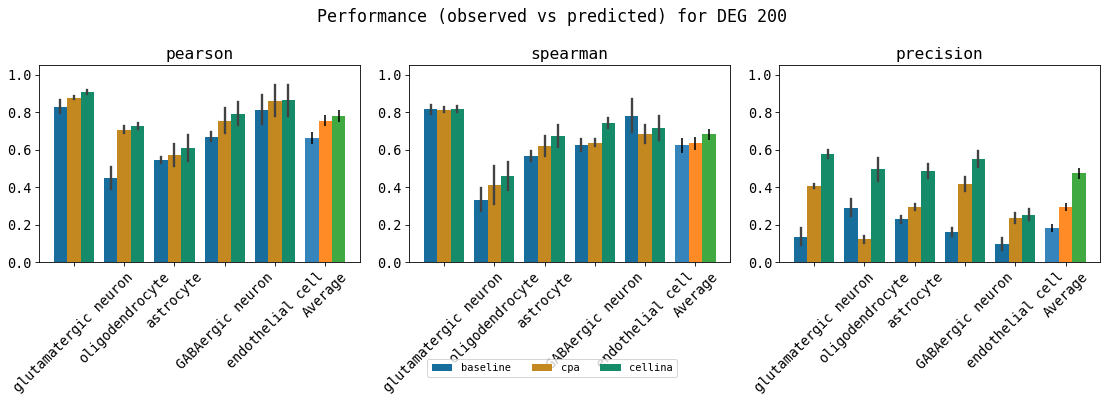

In [67]:
metrics = ["pearson", "spearman", "precision"]
grouping = "cell_type"
model_order = ["baseline", "cpa", "cellina"]

plot_model_comparison(
    combined_df,
    metrics,
    grouping,
    model_order,
    palette='colorblind',
    average_only=False,
    save=False,
    save_name="ood_summary_correlations_200"
)

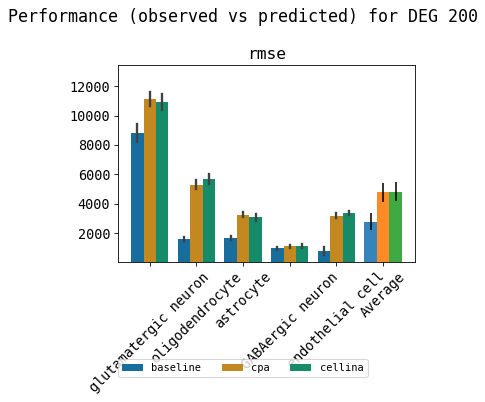

In [68]:
metrics = ["rmse"]
grouping = "cell_type"
model_order = model_order = ["baseline", "cpa", "cellina"]

plot_model_comparison(
    combined_df,
    metrics,
    grouping,
    model_order,
    palette='colorblind',
    average_only=False,
    save=False,
    save_name="ood_summary_correlations_200"
)